# Air Quality Prediction Using Regressor Models

## Linear Regression

Linear Regression Results:
Mean Squared Error: 42.31
R2 Score: 0.97


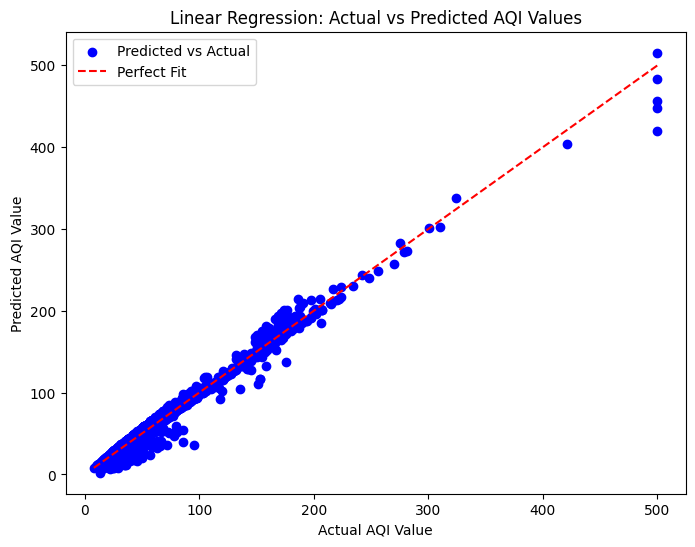

In [1]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler

# Load the dataset
file_path = 'D:\Air-Quality-Prediction\Data\Real-Data\AQI and Lat Long of Countries.csv'
data = pd.read_csv(file_path)

# Data Cleaning and Preparation
data = data.dropna(subset=['Country'])  # Remove rows with missing 'Country'

# Encode AQI Category as numeric
category_map = {
    'Good': 1, 'Moderate': 2, 'Unhealthy for Sensitive Groups': 3,
    'Unhealthy': 4, 'Very Unhealthy': 5, 'Hazardous': 6
}
data['AQI Category Numeric'] = data['AQI Category'].map(category_map)

# Select features and target
features = ['CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value']
X = data[features]
y = data['AQI Value']

# Normalize the features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Apply Linear Regression
linear_regressor = LinearRegression()
linear_regressor.fit(X_train, y_train)

# Make predictions
y_pred_lr = linear_regressor.predict(X_test)

# Evaluate model
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results:")
print(f"Mean Squared Error: {mse_lr:.2f}")
print(f"R2 Score: {r2_lr:.2f}")

# Visualization: Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lr, color='blue', label='Predicted vs Actual')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label='Perfect Fit')
plt.xlabel('Actual AQI Value')
plt.ylabel('Predicted AQI Value')
plt.title('Linear Regression: Actual vs Predicted AQI Values')
plt.legend()
plt.show()



Random Forest Regressor Results:
Mean Squared Error: 2.50
R2 Score: 1.00


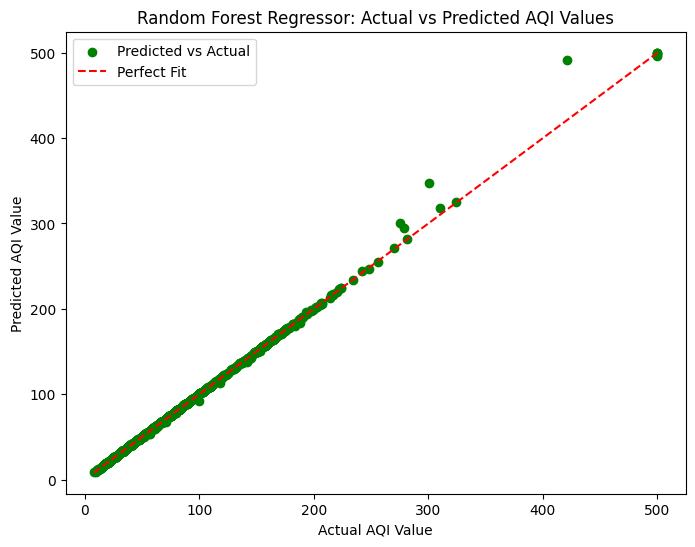

In [2]:
# Import necessary libraries
from sklearn.ensemble import RandomForestRegressor

# Apply Random Forest Regressor
random_forest_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
random_forest_regressor.fit(X_train, y_train)

# Make predictions
y_pred_rf = random_forest_regressor.predict(X_test)

# Evaluate model
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("\nRandom Forest Regressor Results:")
print(f"Mean Squared Error: {mse_rf:.2f}")
print(f"R2 Score: {r2_rf:.2f}")

# Visualization: Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, color='green', label='Predicted vs Actual')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label='Perfect Fit')
plt.xlabel('Actual AQI Value')
plt.ylabel('Predicted AQI Value')
plt.title('Random Forest Regressor: Actual vs Predicted AQI Values')
plt.legend()
plt.show()
